# Parametric working memory: four figures that test the mechanism

## TL;DR

The rank-two network solves all 49 frequency pairs accurately (condition-balanced MSE \(=1.77\times10^{-4}\), \(R^2=0.999\)), while the matched rank-one fit does not (MSE \(=0.112\)). Both aligned recurrent directions are necessary: removing them raises MSE to 0.220 and 0.745.

The learned mechanism is not the paper's clean persistent/transient circuit. The memory-aligned coordinate follows a timed trajectory, the recurrent overlap matrix contains a large cross-coupling (-0.70), and performance degrades away from the trained delay (MSE 0.0156 at the shortest and 0.0377 at the longest tested delay).

For this finite network, a single fitted Gaussian is not sufficient: the mean-field circuit reaches MSE 0.0229 and Gaussian-resampled networks have median MSE 0.306. The figures therefore support a coupled rank-two timing solution, while also showing exactly which additional tests would be required to recover the paper's covariance-only working-memory mechanism.

## Context and methods

The synthetic task uses seven frequencies from 10 to 34 Hz. The first stimulus appears at time steps 5--10, the second at 60--70, and the target is

\[
y = \frac{f_1-f_2}{34-10}.
\]

### Key assumptions

- The main model is trained only at one delay; delay sweeps therefore test generalization rather than training performance.
- We evaluate all 49 frequency pairs with equal weight, avoiding the triangular weighting over differences produced by random sampling.
- The two recurrent factors are not intrinsically ordered. We rotate them without changing the recurrent matrix so that the first axis is the direction that encodes \(f_1\) immediately before the second stimulus.
- Exact circuit overlaps use \(a^\top b/N\). Centered sample correlations are shown separately to describe the loading cloud.

## Setup

In [1]:
from copy import deepcopy

import matplotlib.pyplot as plt
import numpy as np
import torch
from matplotlib.colors import TwoSlopeNorm
from numpy.polynomial.hermite import hermgauss

from low_rank_rnn.model import LowRankRNN
from low_rank_rnn.plotting import COLORS, COVARIANCE_CMAP, set_plot_style
from low_rank_rnn.training import train_model

set_plot_style()

BASE_SEED = 2026
FREQUENCIES = np.array([10, 14, 18, 22, 26, 30, 34], dtype=float)
FREQUENCY_CENTER = FREQUENCIES.mean()
FREQUENCY_RANGE = np.ptp(FREQUENCIES)

FIRST_WINDOW = (5, 10)
TRAINED_SECOND_WINDOW = (60, 70)
DECISION_STEPS = 5
NUM_UNITS = 128
NUM_TRAIN_TRIALS = 200
TRAINING_EPOCHS = 800
TARGET_MSE = 5e-3

torch.manual_seed(BASE_SEED)

## Data

In [2]:
def make_trials(frequency_pairs, *, second_start=TRAINED_SECOND_WINDOW[0]):
    # Create deterministic task inputs and continuous difference targets.
    frequency_pairs = np.asarray(frequency_pairs, dtype=float)
    second_end = second_start + (TRAINED_SECOND_WINDOW[1] - TRAINED_SECOND_WINDOW[0])
    trial_length = second_end + 10

    stimulus_values = (frequency_pairs - FREQUENCY_CENTER) / FREQUENCY_RANGE
    inputs = np.zeros((len(frequency_pairs), trial_length), dtype=np.float32)
    inputs[:, FIRST_WINDOW[0] : FIRST_WINDOW[1] + 1] = stimulus_values[:, 0, None]
    inputs[:, second_start : second_end + 1] = stimulus_values[:, 1, None]
    targets = ((frequency_pairs[:, 0] - frequency_pairs[:, 1]) / FREQUENCY_RANGE).astype(
        np.float32
    )
    return inputs, targets


def random_frequency_pairs(num_trials, rng):
    return rng.choice(FREQUENCIES, size=(num_trials, 2))


def run_model(model, inputs):
    tensor = torch.as_tensor(inputs, dtype=torch.float32)
    model.eval()
    with torch.no_grad():
        outputs, states = model(tensor)
    return outputs.cpu().numpy(), states.cpu().numpy()


def decisions(outputs):
    return outputs[:, -DECISION_STEPS:].mean(axis=1)


f1_grid, f2_grid = np.meshgrid(FREQUENCIES, FREQUENCIES)
grid_pairs = np.column_stack((f1_grid.ravel(), f2_grid.ravel()))
grid_inputs, grid_targets = make_trials(grid_pairs)

training_rng = np.random.default_rng(BASE_SEED)
train_pairs = random_frequency_pairs(NUM_TRAIN_TRIALS, training_rng)
train_inputs, train_targets = make_trials(train_pairs)

print(f"Training trials: {len(train_inputs)}")
print(f"Condition-balanced evaluation pairs: {len(grid_inputs)}")

Training trials: 200
Condition-balanced evaluation pairs: 49


## Train the main rank-two model

In [3]:
torch.manual_seed(BASE_SEED)
rank_two_model = LowRankRNN(NUM_UNITS, rank=2)
rank_two_losses = train_model(
    rank_two_model,
    torch.as_tensor(train_inputs),
    torch.as_tensor(train_targets),
    epochs=TRAINING_EPOCHS,
    batch_size=32,
    decision_steps=DECISION_STEPS,
    log_every=200,
)

grid_outputs, grid_states = run_model(rank_two_model, grid_inputs)
grid_decisions = decisions(grid_outputs)
rank_two_mse = np.mean((grid_decisions - grid_targets) ** 2)
rank_two_r2 = 1 - np.sum((grid_decisions - grid_targets) ** 2) / np.sum(
    (grid_targets - grid_targets.mean()) ** 2
)

print(f"Condition-balanced MSE: {rank_two_mse:.6f}")
print(f"Condition-balanced R²:  {rank_two_r2:.4f}")
assert rank_two_mse < TARGET_MSE, "The rank-two fit did not reach the assignment target."

Epoch 200: loss=0.115002


Epoch 400: loss=0.004609


Epoch 600: loss=0.000548


Epoch 800: loss=0.000247
Condition-balanced MSE: 0.000177
Condition-balanced R²:  0.9992


## Result 1: behavior over the complete stimulus plane

The heatmaps give every frequency pair equal visual and numerical weight. The residual panel is deliberately much more sensitive than the target and prediction panels.

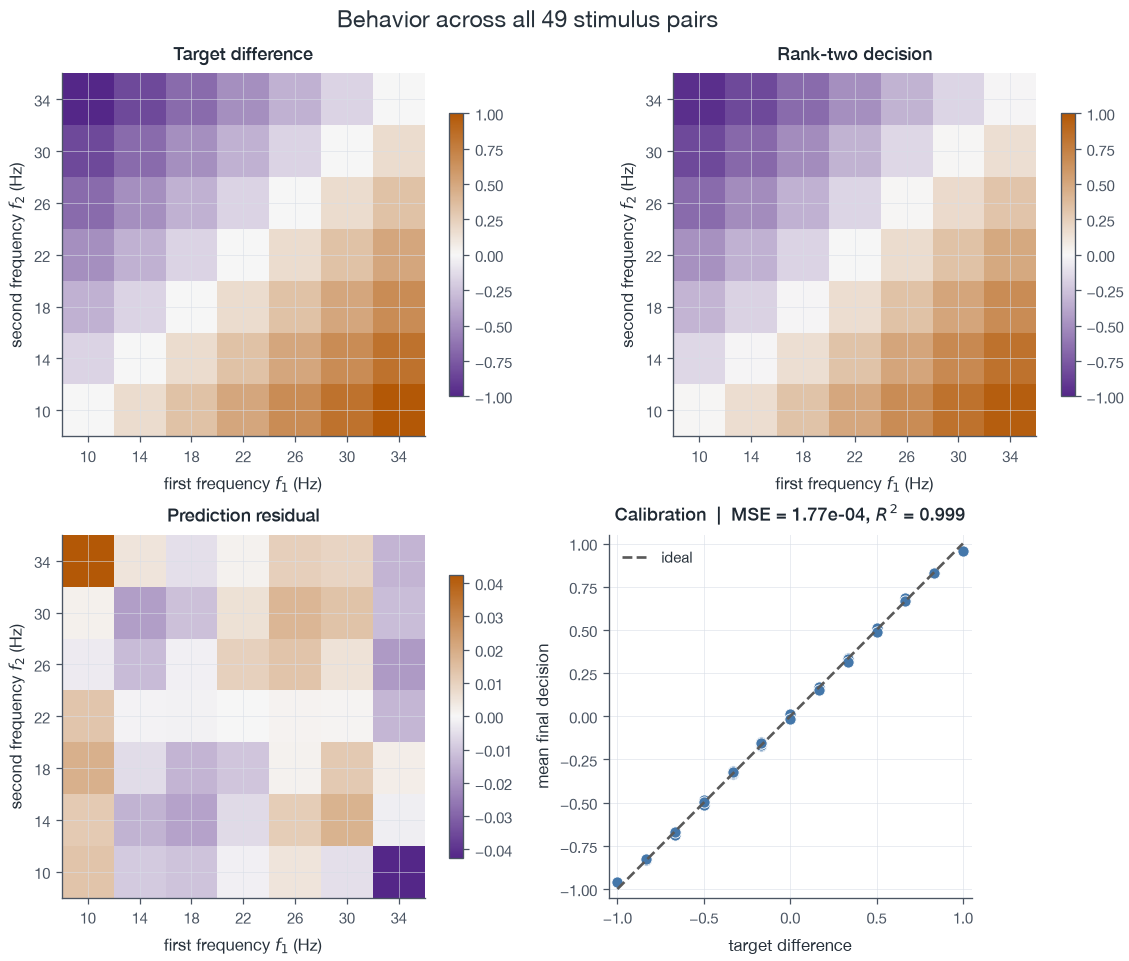

In [4]:
target_matrix = grid_targets.reshape(len(FREQUENCIES), len(FREQUENCIES))
decision_matrix = grid_decisions.reshape(len(FREQUENCIES), len(FREQUENCIES))
residual_matrix = decision_matrix - target_matrix
residual_limit = max(np.max(np.abs(residual_matrix)), 1e-3)

fig, axes = plt.subplots(2, 2, figsize=(10, 8), constrained_layout=True)

for axis, matrix, title in zip(
    axes.flat[:3],
    (target_matrix, decision_matrix, residual_matrix),
    ("Target difference", "Rank-two decision", "Prediction residual"),
):
    limit = 1 if title != "Prediction residual" else residual_limit
    image = axis.imshow(
        matrix,
        origin="lower",
        cmap=COVARIANCE_CMAP,
        norm=TwoSlopeNorm(vmin=-limit, vcenter=0, vmax=limit),
    )
    axis.set_xticks(range(len(FREQUENCIES)), labels=FREQUENCIES.astype(int))
    axis.set_yticks(range(len(FREQUENCIES)), labels=FREQUENCIES.astype(int))
    axis.set_xlabel(r"first frequency $f_1$ (Hz)")
    axis.set_ylabel(r"second frequency $f_2$ (Hz)")
    axis.set_title(title)
    fig.colorbar(image, ax=axis, shrink=0.78)

calibration_axis = axes[1, 1]
calibration_axis.scatter(
    grid_targets,
    grid_decisions,
    color=COLORS["blue"],
    edgecolor="white",
    linewidth=0.5,
    s=45,
)
calibration_axis.plot((-1, 1), (-1, 1), color="0.35", linestyle="--", label="ideal")
calibration_axis.set(
    xlim=(-1.05, 1.05),
    ylim=(-1.05, 1.05),
    xlabel="target difference",
    ylabel="mean final decision",
    title=f"Calibration  |  MSE = {rank_two_mse:.2e}, $R^2$ = {rank_two_r2:.3f}",
)
calibration_axis.set_aspect("equal")
calibration_axis.legend(loc="upper left")

fig.suptitle("Behavior across all 49 stimulus pairs", fontsize=14)
plt.show()

## Result 2: align and inspect the recurrent modes

The state always lies in the span of \([m_1,m_2,I]\). We recover its coefficients with a least-squares decomposition, then apply an orthogonal rotation that leaves \(J=MN^\top/N\) unchanged. The first rotated axis is chosen to maximize the encoding of \(f_1\) at the end of the delay.

In [5]:
def state_coefficients(states, model):
    state_basis = np.column_stack(
        (model.m.detach().cpu().numpy(), model.I.detach().cpu().numpy())
    )
    return np.asarray(states) @ np.linalg.pinv(state_basis).T


grid_coefficients = state_coefficients(grid_states, rank_two_model)
raw_recurrent_coordinates = grid_coefficients[..., :2]
delay_time = TRAINED_SECOND_WINDOW[0] - 1

normalized_f1 = (grid_pairs[:, 0] - FREQUENCY_CENTER) / FREQUENCY_RANGE
design = np.column_stack((np.ones(len(grid_pairs)), normalized_f1))
memory_slope = np.linalg.lstsq(
    design,
    raw_recurrent_coordinates[:, delay_time],
    rcond=None,
)[0][1]
memory_axis = memory_slope / np.linalg.norm(memory_slope)
other_axis = np.array((-memory_axis[1], memory_axis[0]))
mode_rotation = np.column_stack((memory_axis, other_axis))

aligned_m = rank_two_model.m.detach().cpu().numpy() @ mode_rotation
aligned_n = rank_two_model.n.detach().cpu().numpy() @ mode_rotation
aligned_grid_coordinates = raw_recurrent_coordinates @ mode_rotation

print("Orthogonal mode rotation:\n", np.round(mode_rotation, 3))
print(
    "Recurrent-matrix reconstruction error:",
    np.linalg.norm(
        aligned_m @ aligned_n.T
        - rank_two_model.m.detach().cpu().numpy()
        @ rank_two_model.n.detach().cpu().numpy().T
    ),
)

Orthogonal mode rotation:
 [[-0.761  0.648]
 [-0.648 -0.761]]
Recurrent-matrix reconstruction error: 1.076780545508895e-05


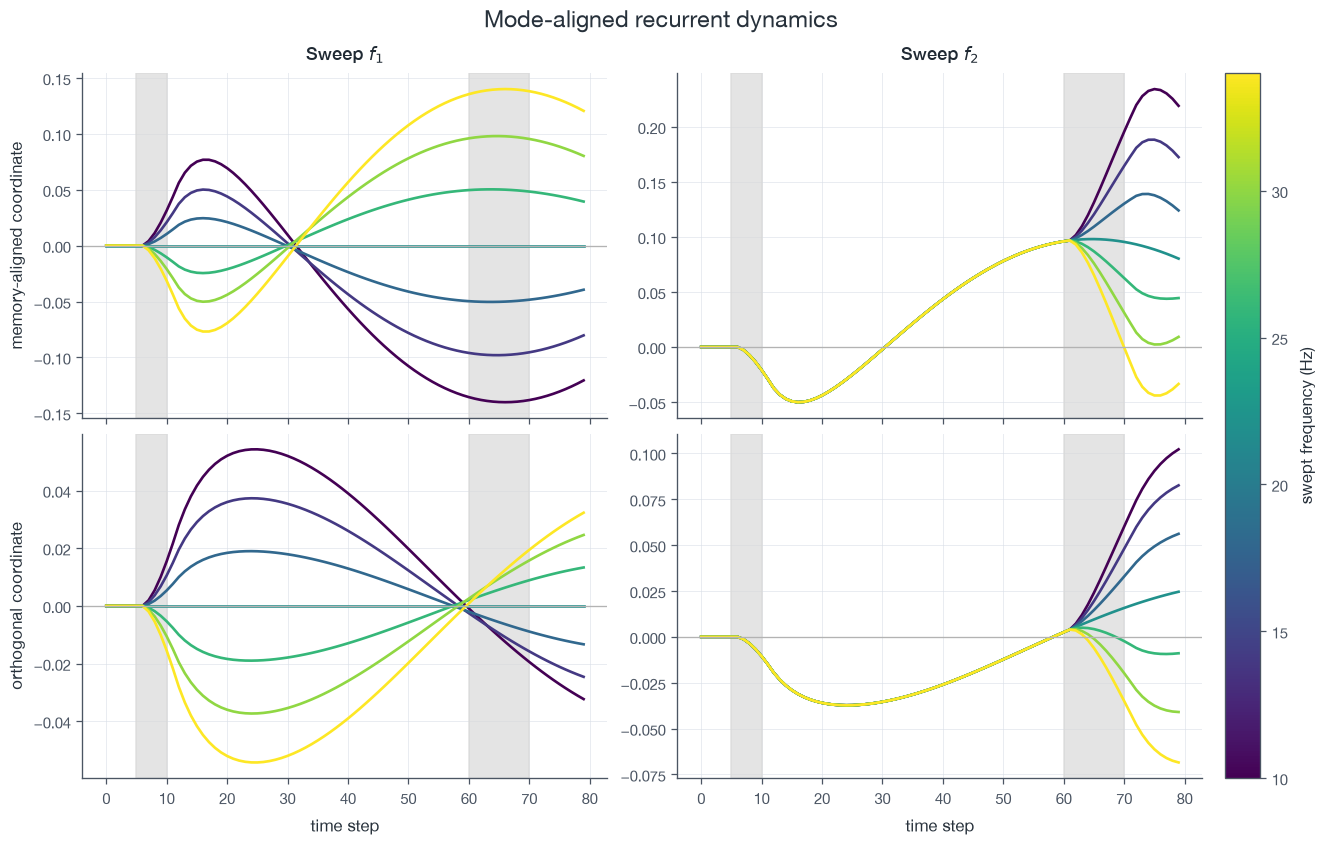

In [6]:
def aligned_coordinates_for_pairs(frequency_pairs):
    inputs, _ = make_trials(frequency_pairs)
    _, states = run_model(rank_two_model, inputs)
    raw_coordinates = state_coefficients(states, rank_two_model)[..., :2]
    return raw_coordinates @ mode_rotation


first_sweep_pairs = np.column_stack(
    (FREQUENCIES, np.full(len(FREQUENCIES), FREQUENCY_CENTER))
)
second_sweep_pairs = np.column_stack(
    (np.full(len(FREQUENCIES), 30.0), FREQUENCIES)
)
first_sweep_coordinates = aligned_coordinates_for_pairs(first_sweep_pairs)
second_sweep_coordinates = aligned_coordinates_for_pairs(second_sweep_pairs)

color_norm = plt.Normalize(FREQUENCIES.min(), FREQUENCIES.max())
color_map = plt.get_cmap("viridis")
time_steps = np.arange(grid_inputs.shape[1])

fig, axes = plt.subplots(2, 2, figsize=(11, 7), sharex=True, constrained_layout=True)
for column, (coordinates, swept_name) in enumerate(
    ((first_sweep_coordinates, r"$f_1$"), (second_sweep_coordinates, r"$f_2$"))
):
    for frequency, trajectory in zip(FREQUENCIES, coordinates):
        color = color_map(color_norm(frequency))
        axes[0, column].plot(time_steps, trajectory[:, 0], color=color)
        axes[1, column].plot(time_steps, trajectory[:, 1], color=color)

    axes[0, column].set_title(f"Sweep {swept_name}")
    axes[1, column].set_xlabel("time step")
    for axis in axes[:, column]:
        axis.axhline(0, color="0.7", linewidth=0.8)
        axis.axvspan(*FIRST_WINDOW, color="0.85", alpha=0.7)
        axis.axvspan(*TRAINED_SECOND_WINDOW, color="0.85", alpha=0.7)

axes[0, 0].set_ylabel("memory-aligned coordinate")
axes[1, 0].set_ylabel("orthogonal coordinate")
colorbar = fig.colorbar(
    plt.cm.ScalarMappable(norm=color_norm, cmap=color_map),
    ax=axes,
    pad=0.02,
)
colorbar.set_label("swept frequency (Hz)")
fig.suptitle("Mode-aligned recurrent dynamics", fontsize=14)
plt.show()

## Result 3: loading geometry becomes an effective circuit

The left panel describes the full loading cloud with centered correlations. The right panel contains the uncentered overlaps that enter the reduced dynamics directly. Off-diagonal entries reveal whether the two modes evolve independently or form a coupled circuit.

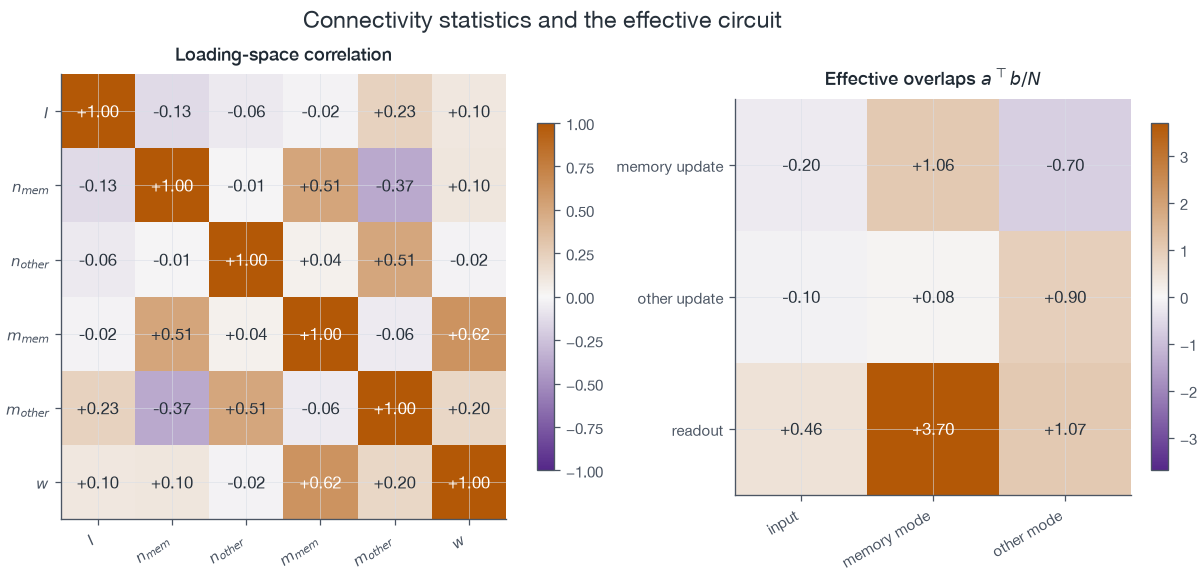

Loading means: {'$I$': np.float64(0.092), '$n_{mem}$': np.float64(0.062), '$n_{other}$': np.float64(-0.002), '$m_{mem}$': np.float64(0.116), '$m_{other}$': np.float64(-0.066), '$w$': np.float64(0.065)}


In [7]:
input_vector = rank_two_model.I.detach().cpu().numpy()
readout_vector = rank_two_model.w.detach().cpu().numpy()

loading_names = (
    r"$I$",
    r"$n_{mem}$",
    r"$n_{other}$",
    r"$m_{mem}$",
    r"$m_{other}$",
    r"$w$",
)
loading_samples = np.column_stack(
    (input_vector, aligned_n, aligned_m, readout_vector)
)
loading_mean = loading_samples.mean(axis=0)
loading_covariance = np.cov(loading_samples, rowvar=False, bias=True)
loading_correlation = np.corrcoef(loading_samples, rowvar=False)

input_overlaps = aligned_n.T @ input_vector / NUM_UNITS
recurrent_overlaps = aligned_n.T @ aligned_m / NUM_UNITS
readout_overlaps = readout_vector @ aligned_m / NUM_UNITS
direct_input_overlap = readout_vector @ input_vector / NUM_UNITS

circuit_overlaps = np.array(
    [
        [input_overlaps[0], recurrent_overlaps[0, 0], recurrent_overlaps[0, 1]],
        [input_overlaps[1], recurrent_overlaps[1, 0], recurrent_overlaps[1, 1]],
        [direct_input_overlap, readout_overlaps[0], readout_overlaps[1]],
    ]
)


def annotate_heatmap(axis, matrix, *, threshold):
    for row in range(matrix.shape[0]):
        for column in range(matrix.shape[1]):
            value = matrix[row, column]
            color = "white" if abs(value) > threshold else "#27313B"
            axis.text(column, row, f"{value:+.2f}", ha="center", va="center", color=color)


fig, axes = plt.subplots(
    1,
    2,
    figsize=(11, 4.8),
    gridspec_kw={"width_ratios": (1.25, 0.8)},
    constrained_layout=True,
)

correlation_image = axes[0].imshow(
    loading_correlation,
    cmap=COVARIANCE_CMAP,
    vmin=-1,
    vmax=1,
)
axes[0].set_xticks(range(6), labels=loading_names, rotation=35, ha="right")
axes[0].set_yticks(range(6), labels=loading_names)
axes[0].set_title("Loading-space correlation")
annotate_heatmap(axes[0], loading_correlation, threshold=0.55)
fig.colorbar(correlation_image, ax=axes[0], shrink=0.78)

circuit_limit = max(np.max(np.abs(circuit_overlaps)), 1e-6)
circuit_image = axes[1].imshow(
    circuit_overlaps,
    cmap=COVARIANCE_CMAP,
    norm=TwoSlopeNorm(vmin=-circuit_limit, vcenter=0, vmax=circuit_limit),
)
axes[1].set_xticks(
    range(3), labels=("input", "memory mode", "other mode"), rotation=30, ha="right"
)
axes[1].set_yticks(
    range(3), labels=("memory update", "other update", "readout")
)
axes[1].set_title(r"Effective overlaps $a^\top b/N$")
annotate_heatmap(axes[1], circuit_overlaps, threshold=0.55 * circuit_limit)
fig.colorbar(circuit_image, ax=axes[1], shrink=0.78)

fig.suptitle("Connectivity statistics and the effective circuit", fontsize=14)
plt.show()

print("Loading means:", dict(zip(loading_names, np.round(loading_mean, 3))))

## Result 4: causal and reduced-model tests

Three tests ask different questions:

- **Mode removal:** is each recurrent direction necessary in the chosen memory-aligned basis?
- **Gaussian resampling / mean field:** are loading means and covariances sufficient?
- **Delay sweep:** did the fixed-delay training produce robust memory or a timed trajectory?

In [8]:
def aligned_copy(model):
    copied = deepcopy(model)
    with torch.no_grad():
        copied.m.copy_(torch.as_tensor(aligned_m, dtype=copied.m.dtype))
        copied.n.copy_(torch.as_tensor(aligned_n, dtype=copied.n.dtype))
    return copied


def remove_mode(model, mode_index):
    ablated = aligned_copy(model)
    with torch.no_grad():
        ablated.m[:, mode_index].zero_()
        ablated.n[:, mode_index].zero_()
    return ablated


def model_mse(model, inputs, targets):
    outputs, _ = run_model(model, inputs)
    return float(np.mean((decisions(outputs) - targets) ** 2))


memory_removed_model = remove_mode(rank_two_model, 0)
other_removed_model = remove_mode(rank_two_model, 1)
memory_removed_mse = model_mse(memory_removed_model, grid_inputs, grid_targets)
other_removed_mse = model_mse(other_removed_model, grid_inputs, grid_targets)

print(f"Memory-mode removal MSE: {memory_removed_mse:.4f}")
print(f"Other-mode removal MSE:  {other_removed_mse:.4f}")

Memory-mode removal MSE: 0.2204
Other-mode removal MSE:  0.7453


In [9]:
# A rank-one comparison is intentionally trained with the same data and optimizer.
torch.manual_seed(BASE_SEED + 1)
rank_one_model = LowRankRNN(NUM_UNITS, rank=1)
rank_one_losses = train_model(
    rank_one_model,
    torch.as_tensor(train_inputs),
    torch.as_tensor(train_targets),
    epochs=TRAINING_EPOCHS,
    batch_size=32,
    decision_steps=DECISION_STEPS,
    log_every=200,
)
rank_one_mse = model_mse(rank_one_model, grid_inputs, grid_targets)
print(f"Rank-one condition-balanced MSE: {rank_one_mse:.6f}")

Epoch 200: loss=0.115226


Epoch 400: loss=0.115221


Epoch 600: loss=0.115252


Epoch 800: loss=0.115163
Rank-one condition-balanced MSE: 0.111804


In [10]:
gaussian_mean = loading_samples.mean(axis=0)
gaussian_covariance = np.cov(loading_samples, rowvar=False, bias=True)
gauss_nodes, gauss_weights = hermgauss(40)
standard_normal_nodes = np.sqrt(2) * gauss_nodes
standard_normal_weights = gauss_weights / np.sqrt(np.pi)

input_index = 0
n_indices = np.array((1, 2))
m_indices = np.array((3, 4))
readout_index = 5
basis_indices = np.array((input_index, *m_indices))


def gaussian_rate_statistics(coefficients):
    basis_mean = gaussian_mean[basis_indices]
    basis_covariance = gaussian_covariance[np.ix_(basis_indices, basis_indices)]
    current_mean = coefficients @ basis_mean
    current_variance = np.einsum(
        "bi,ij,bj->b", coefficients, basis_covariance, coefficients
    )
    currents = current_mean[:, None] + np.sqrt(
        np.maximum(current_variance, 0)
    )[:, None] * standard_normal_nodes
    rates = np.tanh(currents)
    mean_rate = rates @ standard_normal_weights
    mean_gain = (1 - rates**2) @ standard_normal_weights
    return mean_rate, mean_gain


def gaussian_mean_field(inputs):
    # Simulate the two recurrent coordinates plus the filtered input coordinate.
    inputs = np.asarray(inputs)
    batch_size, num_steps = inputs.shape
    recurrent_state = np.zeros((batch_size, 2))
    filtered_input = np.zeros(batch_size)
    outputs = np.empty((batch_size, num_steps))

    for time in range(num_steps):
        coefficients = np.column_stack((filtered_input, recurrent_state))
        mean_rate, mean_gain = gaussian_rate_statistics(coefficients)

        cov_n_current = (
            gaussian_covariance[np.ix_(n_indices, basis_indices)] @ coefficients.T
        ).T
        recurrent_drive = (
            gaussian_mean[n_indices][None, :] * mean_rate[:, None]
            + cov_n_current * mean_gain[:, None]
        )

        cov_w_current = (
            gaussian_covariance[readout_index, basis_indices] * coefficients
        ).sum(axis=1)
        outputs[:, time] = (
            gaussian_mean[readout_index] * mean_rate + cov_w_current * mean_gain
        )

        recurrent_state += rank_two_model.step_size * (
            -recurrent_state + recurrent_drive
        )
        filtered_input += rank_two_model.step_size * (
            -filtered_input + inputs[:, time]
        )

    return outputs


mean_field_outputs = gaussian_mean_field(grid_inputs)
mean_field_mse = float(np.mean((decisions(mean_field_outputs) - grid_targets) ** 2))


def network_from_gaussian_samples(samples):
    network = LowRankRNN(NUM_UNITS, rank=2)
    with torch.no_grad():
        network.I.copy_(torch.as_tensor(samples[:, 0], dtype=network.I.dtype))
        network.n.copy_(torch.as_tensor(samples[:, 1:3], dtype=network.n.dtype))
        network.m.copy_(torch.as_tensor(samples[:, 3:5], dtype=network.m.dtype))
        network.w.copy_(torch.as_tensor(samples[:, 5], dtype=network.w.dtype))
    return network


resample_rng = np.random.default_rng(BASE_SEED + 10_000)
resampled_mses = []
for _ in range(10):
    samples = resample_rng.multivariate_normal(
        gaussian_mean, gaussian_covariance, size=NUM_UNITS
    )
    resampled_mses.append(
        model_mse(network_from_gaussian_samples(samples), grid_inputs, grid_targets)
    )
resampled_mses = np.asarray(resampled_mses)

print(f"Gaussian mean-field MSE: {mean_field_mse:.6f}")
print(
    "Gaussian-resampled MSE, median [range]: "
    f"{np.median(resampled_mses):.4f} "
    f"[{resampled_mses.min():.4f}, {resampled_mses.max():.4f}]"
)

Gaussian mean-field MSE: 0.022866
Gaussian-resampled MSE, median [range]: 0.3062 [0.0615, 1.8114]


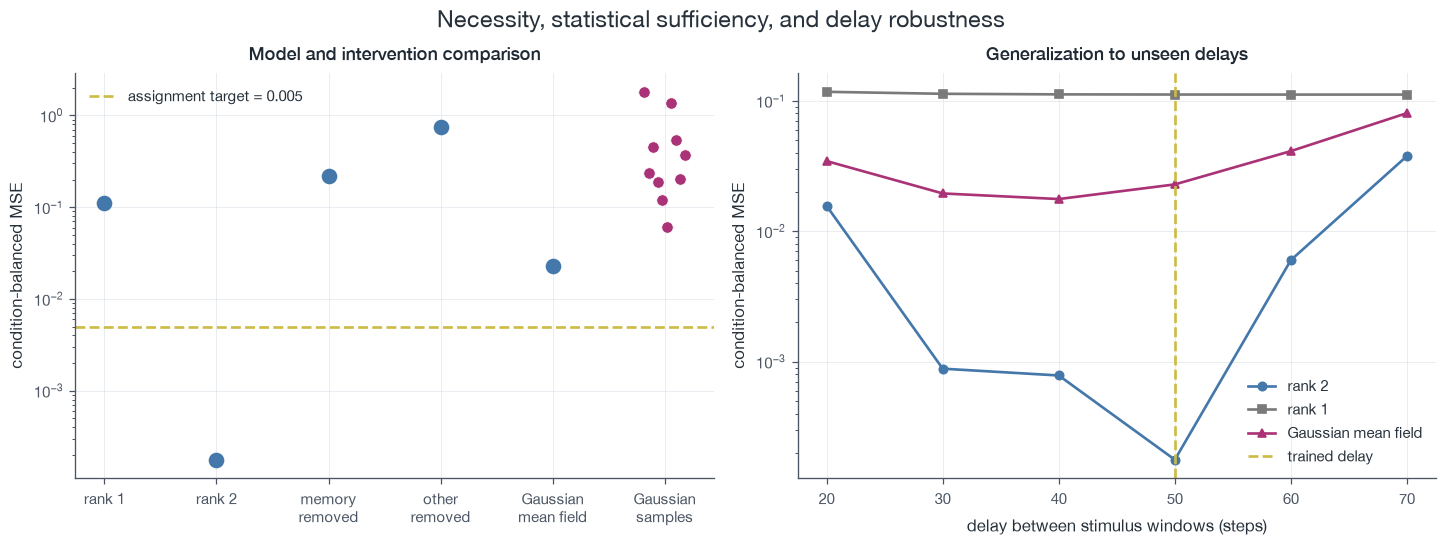

In [11]:
second_starts = np.array((30, 40, 50, 60, 70, 80))
delay_lengths = second_starts - FIRST_WINDOW[1]
rank_two_delay_mse = []
rank_one_delay_mse = []
mean_field_delay_mse = []

for second_start in second_starts:
    delayed_inputs, delayed_targets = make_trials(
        grid_pairs, second_start=int(second_start)
    )
    rank_two_delay_mse.append(model_mse(rank_two_model, delayed_inputs, delayed_targets))
    rank_one_delay_mse.append(model_mse(rank_one_model, delayed_inputs, delayed_targets))
    reduced_outputs = gaussian_mean_field(delayed_inputs)
    mean_field_delay_mse.append(
        np.mean((decisions(reduced_outputs) - delayed_targets) ** 2)
    )

rank_two_delay_mse = np.asarray(rank_two_delay_mse)
rank_one_delay_mse = np.asarray(rank_one_delay_mse)
mean_field_delay_mse = np.asarray(mean_field_delay_mse)

fig, axes = plt.subplots(1, 2, figsize=(12, 4.5), constrained_layout=True)

categories = (
    "rank 1",
    "rank 2",
    "memory\nremoved",
    "other\nremoved",
    "Gaussian\nmean field",
    "Gaussian\nsamples",
)
category_values = (
    rank_one_mse,
    rank_two_mse,
    memory_removed_mse,
    other_removed_mse,
    mean_field_mse,
)
axes[0].scatter(
    np.arange(len(category_values)),
    category_values,
    color=COLORS["blue"],
    s=70,
    zorder=3,
)
jitter = np.linspace(-0.18, 0.18, len(resampled_mses))
axes[0].scatter(
    5 + jitter,
    resampled_mses,
    color=COLORS["purple"],
    edgecolor="white",
    linewidth=0.5,
    s=48,
    zorder=3,
)
axes[0].axhline(
    TARGET_MSE,
    color=COLORS["gold"],
    linestyle="--",
    label=f"assignment target = {TARGET_MSE:g}",
)
axes[0].set_yscale("log")
axes[0].set_xticks(range(len(categories)), labels=categories)
axes[0].set_ylabel("condition-balanced MSE")
axes[0].set_title("Model and intervention comparison")
axes[0].legend(loc="upper left")

axes[1].plot(
    delay_lengths,
    rank_two_delay_mse,
    marker="o",
    color=COLORS["blue"],
    label="rank 2",
)
axes[1].plot(
    delay_lengths,
    rank_one_delay_mse,
    marker="s",
    color=COLORS["gray"],
    label="rank 1",
)
axes[1].plot(
    delay_lengths,
    mean_field_delay_mse,
    marker="^",
    color=COLORS["purple"],
    label="Gaussian mean field",
)
axes[1].axvline(
    TRAINED_SECOND_WINDOW[0] - FIRST_WINDOW[1],
    color=COLORS["gold"],
    linestyle="--",
    label="trained delay",
)
axes[1].set_yscale("log")
axes[1].set_xlabel("delay between stimulus windows (steps)")
axes[1].set_ylabel("condition-balanced MSE")
axes[1].set_title("Generalization to unseen delays")
axes[1].legend(loc="best")

fig.suptitle("Necessity, statistical sufficiency, and delay robustness", fontsize=14)
plt.show()

## Takeaways

- **Behavior:** the complete response surface is nearly perfectly calibrated; the residual scale is only about \(\pm0.04\).
- **Dimensionality:** the rank-two fit reaches MSE \(1.77\times10^{-4}\), whereas the single matched rank-one fit remains at 0.112. A publication-strength minimal-rank claim would still repeat both ranks across initializations.
- **Dynamics:** neither aligned coordinate is a stationary memory trace. The first-stimulus information is carried by a reproducible, evolving trajectory, and the large off-diagonal recurrent overlap shows that the two modes interact.
- **Causality:** removing either aligned direction destroys the computation, with the orthogonal direction especially important for the final comparison.
- **Statistical reduction:** Gaussian mean field and direct Gaussian resampling do not preserve performance for this fit, so the six-dimensional covariance is not yet a sufficient description at \(N=128\).
- **Working memory:** performance is excellent at the trained delay and nearby delays but deteriorates at the extremes, indicating substantial timing dependence.

The scientifically honest conclusion is therefore narrower than the paper's canonical mechanism: this fixed-delay assignment produced an accurate, coupled rank-two solution. Variable-delay training, multiple seeds, and successful Gaussian resampling would be needed to establish the stronger persistent/transient and covariance-sufficiency claims.

In [12]:
summary = {
    "rank_two_mse": rank_two_mse,
    "rank_two_r2": rank_two_r2,
    "rank_one_mse": rank_one_mse,
    "memory_removed_mse": memory_removed_mse,
    "other_removed_mse": other_removed_mse,
    "mean_field_mse": mean_field_mse,
    "resampled_median_mse": float(np.median(resampled_mses)),
    "trained_delay_mse": float(
        rank_two_delay_mse[np.where(second_starts == TRAINED_SECOND_WINDOW[0])[0][0]]
    ),
    "shortest_delay_mse": float(rank_two_delay_mse[0]),
    "longest_delay_mse": float(rank_two_delay_mse[-1]),
}
summary

{'rank_two_mse': np.float32(0.00017696855),
 'rank_two_r2': np.float32(0.9992036),
 'rank_one_mse': 0.1118042841553688,
 'memory_removed_mse': 0.2203768640756607,
 'other_removed_mse': 0.7452961802482605,
 'mean_field_mse': 0.022865776604416906,
 'resampled_median_mse': 0.306242972612381,
 'trained_delay_mse': 0.00017696854774840176,
 'shortest_delay_mse': 0.015634475275874138,
 'longest_delay_mse': 0.0377470962703228}